In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

RAW            = '../data/bus_2025-07-28_2025-08-03.parquet'
DROP_THRESHOLD = 100
EARTH_R        = 6371000  # metres

## 1. 读数据，计算 GPS 速度

In [2]:
df = (
    pl.read_parquet(RAW, columns=['tst_iso', 'fzg_id', 'distanz', 'tuerkriterium', 'pos_lat', 'pos_lon'])
    .with_columns(pl.col('tst_iso').str.to_datetime(format='%Y-%m-%dT%H:%M:%S%.f%z'))
    .sort(['fzg_id', 'tst_iso'])
    .with_columns([
        pl.int_range(pl.len()).over('fzg_id').alias('row_idx'),
        pl.col('distanz').diff().over('fzg_id').alias('delta'),
        pl.col('tst_iso').diff().over('fzg_id').dt.total_seconds().alias('dt'),
        pl.col('pos_lat').shift(1).over('fzg_id').alias('lat_prev'),
        pl.col('pos_lon').shift(1).over('fzg_id').alias('lon_prev'),
    ])
)

# Haversine 距离（metre），然后除以 dt 得 m/s
df = df.with_columns([
    (
        2 * EARTH_R * (
            (
                ((pl.col('pos_lat') - pl.col('lat_prev')) * np.pi / 180 / 2).sin().pow(2)
                + (pl.col('pos_lat') * np.pi / 180).cos()
                * (pl.col('lat_prev') * np.pi / 180).cos()
                * ((pl.col('pos_lon') - pl.col('lon_prev')) * np.pi / 180 / 2).sin().pow(2)
            ).sqrt().arcsin()
        )
    ).alias('gps_dist_m')
]).with_columns(
    pl.when(pl.col('dt').is_null() | (pl.col('dt') <= 0))
        .then(pl.lit(None))
    .otherwise(
        pl.col('gps_dist_m') / pl.col('dt')
    )
    .alias('gps_speed_ms')
)

# distanz 速度（对比用）
df = df.with_columns(
    pl.when(pl.col('delta') < -DROP_THRESHOLD)
        .then(pl.lit(-1.0))
    .when(pl.col('delta') < 0)
        .then(pl.lit(None))
    .when(pl.col('dt').is_null() | (pl.col('dt') == 0))
        .then(pl.lit(None))
    .otherwise(pl.col('delta') / pl.col('dt'))
    .alias('dist_speed_ms')
)

print(f'Total rows: {len(df):,}  |  Vehicles: {df["fzg_id"].n_unique()}')
print(f'gps_speed_ms null: {df["gps_speed_ms"].is_null().sum():,}')

Total rows: 5,728,505  |  Vehicles: 417
gps_speed_ms null: 197,958


## 2. GPS 速度分布

=== GPS 速度分布（m/s）===
  p0  :      0.000 m/s
  p25 :      0.000 m/s
  p50 :      2.216 m/s
  p75 :      8.627 m/s
  p90 :     13.211 m/s
  p95 :     17.167 m/s
  p99 :     44.371 m/s
  p100: 118919.612 m/s
  speed == 0: 2,062,256  (37.3%)


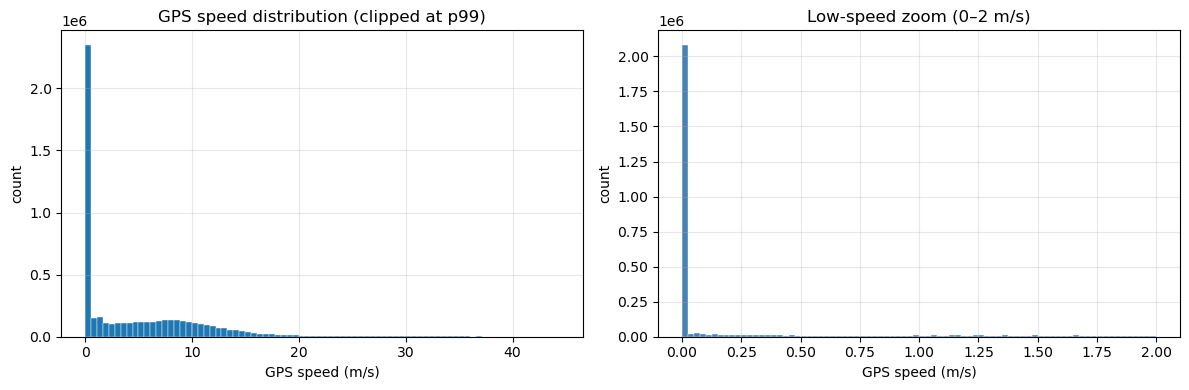

In [3]:
gps = df['gps_speed_ms'].drop_nulls().to_numpy()

print('=== GPS 速度分布（m/s）===')
for p in [0, 25, 50, 75, 90, 95, 99, 100]:
    print(f'  p{p:<3d}: {np.percentile(gps, p):>10.3f} m/s')
print(f'  speed == 0: {(gps == 0).sum():,}  ({(gps == 0).mean()*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

clip = np.percentile(gps, 99)
axes[0].hist(gps[gps <= clip], bins=80, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('GPS speed (m/s)')
axes[0].set_ylabel('count')
axes[0].set_title('GPS speed distribution (clipped at p99)')
axes[0].grid(alpha=0.3)

low = gps[gps <= 2]
axes[1].hist(low, bins=80, edgecolor='white', linewidth=0.3, color='steelblue')
axes[1].set_xlabel('GPS speed (m/s)')
axes[1].set_ylabel('count')
axes[1].set_title('Low-speed zoom (0–2 m/s)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 3. GPS 速度 vs distanz 速度对比

In [4]:
# 两种速度都有值的正常行
both = df.filter(
    pl.col('gps_speed_ms').is_not_null() &
    (pl.col('dist_speed_ms') >= 0)
)

g = both['gps_speed_ms'].to_numpy()
d = both['dist_speed_ms'].to_numpy()

print(f'共同有效行: {len(both):,}')
print()
print('=== 两者同时为 0（都认为静止）===')
both_zero = (g == 0) & (d == 0)
print(f'  {both_zero.sum():,}  ({both_zero.mean()*100:.1f}%)')
print()
print('=== GPS=0 但 distanz>0（distanz 认为在动，GPS 认为静止）===')
gps_static_dist_moving = (g == 0) & (d > 0)
print(f'  {gps_static_dist_moving.sum():,}  ({gps_static_dist_moving.mean()*100:.1f}%)')
print()
print('=== GPS>0 但 distanz=0（GPS 认为在动，distanz 认为静止）===')
gps_moving_dist_static = (g > 0) & (d == 0)
print(f'  {gps_moving_dist_static.sum():,}  ({gps_moving_dist_static.mean()*100:.1f}%)')
if gps_moving_dist_static.sum() > 0:
    print(f'  GPS speed 中位数: {np.median(g[gps_moving_dist_static]):.3f} m/s')

共同有效行: 4,871,061

=== 两者同时为 0（都认为静止）===
  1,954,662  (40.1%)

=== GPS=0 但 distanz>0（distanz 认为在动，GPS 认为静止）===
  64,451  (1.3%)

=== GPS>0 但 distanz=0（GPS 认为在动，distanz 认为静止）===
  338,686  (7.0%)
  GPS speed 中位数: 0.600 m/s


## 4. 门事件发生时的 GPS 速度

验证：开门（0→1）和关门（1→0）发生时 GPS 速度是否接近 0。

=== 开门（0→1） GPS speed 分布 ===
  总计:           363,402
  speed == 0:     51,352  (14.1%)
  speed < 0.5 m/s: 95,126  (26.2%)
  speed < 1.0 m/s: 108,455  (29.8%)
  speed < 2.0 m/s: 137,856  (37.9%)
  speed >= 2 m/s: 225,546  (62.1%)
  中位数:         3.264 m/s

=== 关门（1→0） GPS speed 分布 ===
  总计:           348,118
  speed == 0:     5,680  (1.6%)
  speed < 0.5 m/s: 6,881  (2.0%)
  speed < 1.0 m/s: 22,011  (6.3%)
  speed < 2.0 m/s: 120,483  (34.6%)
  speed >= 2 m/s: 227,635  (65.4%)
  中位数:         3.360 m/s



/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_67566/1141452787.py:36: UserWarning: Glyph 24320 (\N{CJK UNIFIED IDEOGRAPH-5F00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_67566/1141452787.py:36: UserWarning: Glyph 38376 (\N{CJK UNIFIED IDEOGRAPH-95E8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_67566/1141452787.py:36: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_67566/1141452787.py:36: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxcfp6vx34d70nm8knsjxpsc0000gn/T/ipykernel_67566/1141452787.py:36: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/jg/lxc

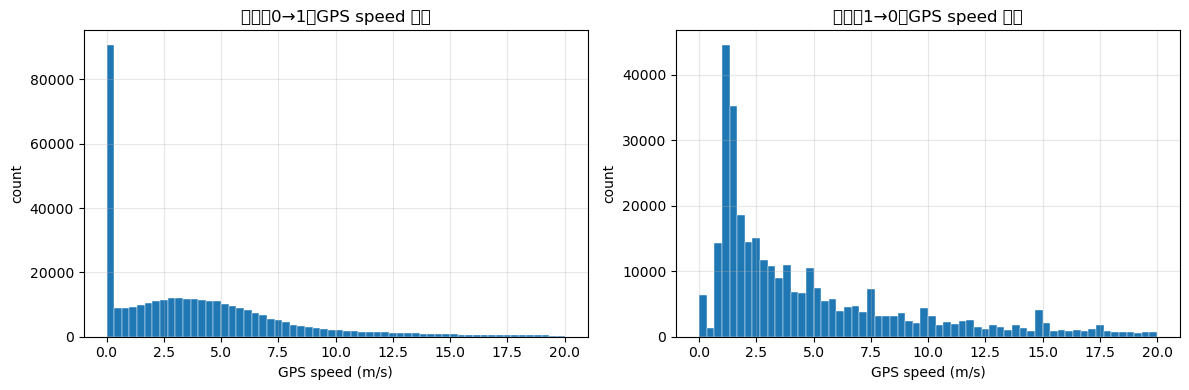

In [5]:
door_events = df.with_columns([
    (
        (pl.col('tuerkriterium').shift(1).over('fzg_id') == False) &
        (pl.col('tuerkriterium') == True)
    ).alias('is_open'),
    (
        (pl.col('tuerkriterium').shift(1).over('fzg_id') == True) &
        (pl.col('tuerkriterium') == False)
    ).alias('is_close'),
])

opens  = door_events.filter(pl.col('is_open'))['gps_speed_ms'].drop_nulls().to_numpy()
closes = door_events.filter(pl.col('is_close'))['gps_speed_ms'].drop_nulls().to_numpy()

for label, arr in [('开门（0→1）', opens), ('关门（1→0）', closes)]:
    print(f'=== {label} GPS speed 分布 ===')
    print(f'  总计:           {len(arr):,}')
    print(f'  speed == 0:     {(arr == 0).sum():,}  ({(arr == 0).mean()*100:.1f}%)')
    for thr in [0.5, 1.0, 2.0]:
        print(f'  speed < {thr} m/s: {(arr < thr).sum():,}  ({(arr < thr).mean()*100:.1f}%)')
    print(f'  speed >= 2 m/s: {(arr >= 2).sum():,}  ({(arr >= 2).mean()*100:.1f}%)')
    print(f'  中位数:         {np.median(arr):.3f} m/s')
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, arr, title in [
    (axes[0], opens,  '开门（0→1）GPS speed 分布'),
    (axes[1], closes, '关门（1→0）GPS speed 分布'),
]:
    clip = min(np.percentile(arr, 99), 20)
    ax.hist(arr[arr <= clip], bins=60, edgecolor='white', linewidth=0.3)
    ax.set_xlabel('GPS speed (m/s)')
    ax.set_ylabel('count')
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 单站可视化：GPS speed + tuerkriterium

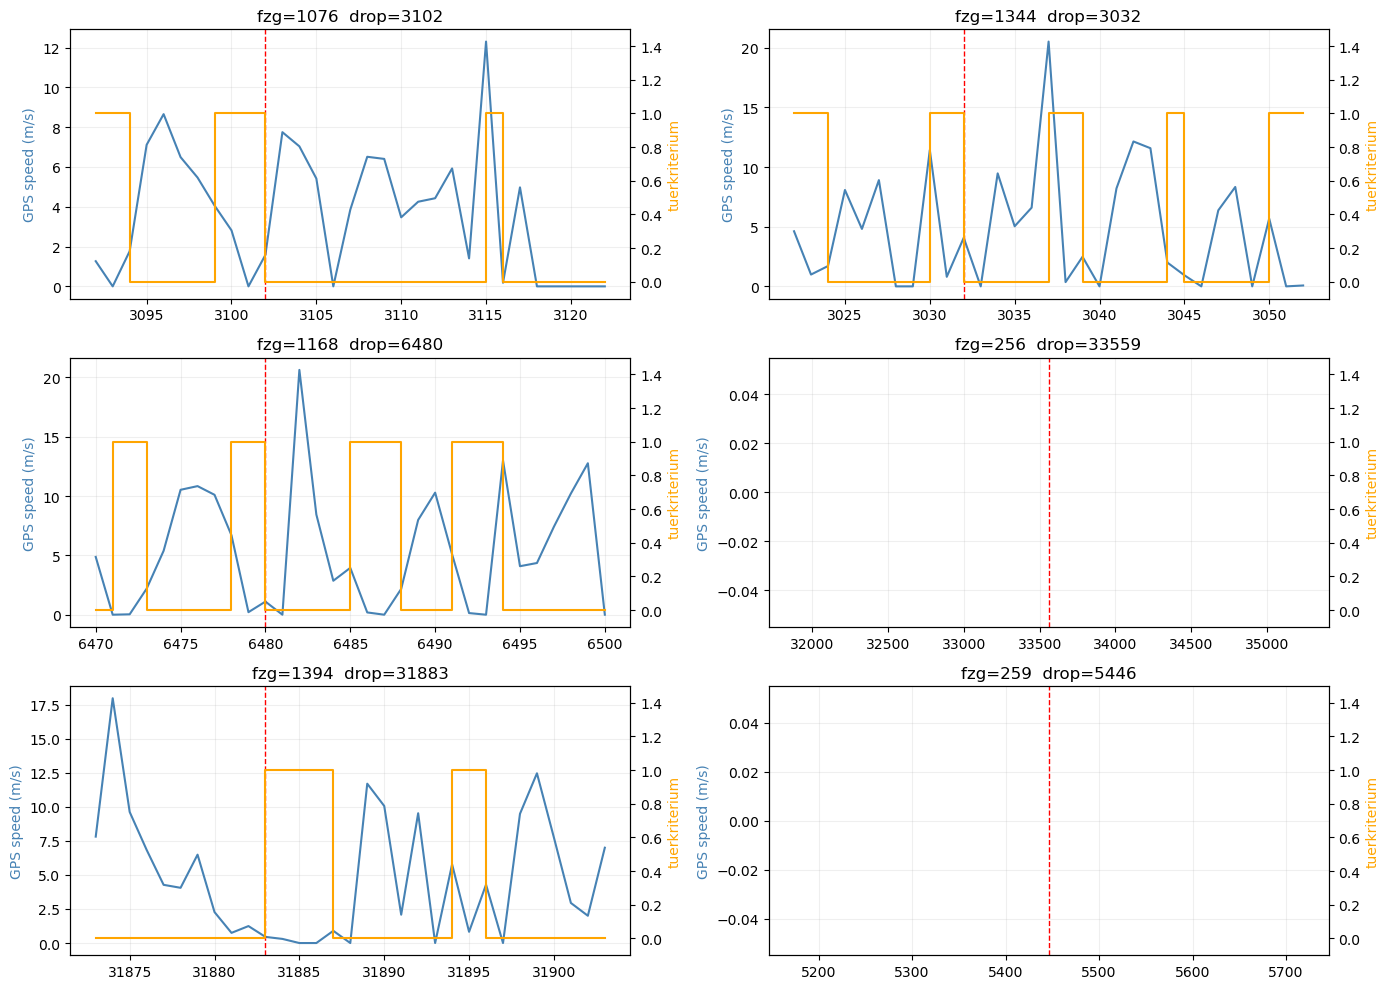

In [6]:
stop_events = pl.read_parquet('../data/processed/core_stop_events.parquet')

sample = (
    stop_events
    .filter(pl.col('stop_status') == 'normal')
    .filter(pl.col('dwell_time') > 5)
    .sample(6, seed=0)
)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, row in zip(axes, sample.iter_rows(named=True)):
    vid          = row['fzg_id']
    drop_row_idx = row['drop_row_idx']

    win = (
        df.filter(pl.col('fzg_id') == vid)
        .filter(pl.col('row_idx').is_between(drop_row_idx - 10, drop_row_idx + 20))
        .sort('row_idx')
    )

    t     = win['row_idx'].to_numpy()
    gspd  = win['gps_speed_ms'].to_numpy().astype(float)
    door  = win['tuerkriterium'].to_numpy().astype(float)

    gspd_plot = np.where(np.isnan(gspd), 0, gspd)

    ax2 = ax.twinx()
    ax.plot(t, gspd_plot, color='steelblue', linewidth=1.5, label='GPS speed (m/s)')
    ax2.step(t, door, color='orange', linewidth=1.5, where='post', label='door')
    ax.axvline(drop_row_idx, color='red', linestyle='--', linewidth=1, label='drop')

    ax.set_ylabel('GPS speed (m/s)', color='steelblue')
    ax2.set_ylabel('tuerkriterium', color='orange')
    ax2.set_ylim(-0.1, 1.5)
    ax.set_title(f'fzg={vid}  drop={drop_row_idx}')
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()